In [3]:
import oracledb
print(oracledb.__version__)


3.4.1


In [4]:
import pandas as pd
import oracledb
df = pd.read_csv(r"C:\Users\preet\Downloads\hotel_bookings.csv")
df.shape
df.head()




,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
import oracledb

# Oracle connection
conn = oracledb.connect(
    user="your_username",
    password="your_password",
    dsn="Host:Port/Service"
)

cursor = conn.cursor()
print("Connected to Oracle successfully!")


Connected to Oracle successfully!


In [6]:
# Replace NaN values
df = df.fillna({
    "children": 0,
    "country": "Unknown",
    "agent": "0",
    "company": "0"
})

# For any remaining NaN
df = df.fillna(0)


In [7]:
text_columns = [
    "hotel", "arrival_date_month", "meal", "country",
    "market_segment", "distribution_channel",
    "reserved_room_type", "assigned_room_type"
]

for col in text_columns:
    df[col] = df[col].astype(str)


In [8]:
import numpy as np

# Replace NaN with None (Oracle-friendly)
df = df.replace({np.nan: None})


In [9]:
text_columns = [
    "hotel", "arrival_date_month", "meal", "country",
    "market_segment", "distribution_channel",
    "reserved_room_type", "assigned_room_type"
]

for col in text_columns:
    df[col] = df[col].astype(str)


In [10]:
df[text_columns] = df[text_columns].replace("nan", None)


In [11]:
df.columns


Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [17]:
insert_sql = """
INSERT INTO hotel_bookings (
    hotel, is_canceled, lead_time, arrival_date_year,
    arrival_date_month, arrival_date_week_number,
    arrival_date_day_of_month, stays_in_weekend_nights,
    stays_in_week_nights, adults, children, babies,
    meal, country, market_segment, distribution_channel,is_repeated_guest,previous_cancellations,
    previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,
    company,days_in_waiting_list,customer_type,adr,
    required_car_parking_spaces, total_of_special_requests,reservation_status,reservation_status_date
) VALUES (
    :1,:2,:3,:4,:5,:6,:7,:8,:9,:10,
    :11,:12,:13,:14,:15,:16,:17,:18,:19,:20,:21,:22,:23,:24,:25,:26,:27,:28,:29,:30,:31,:32
)
"""
# Convert all columns to string
df = df.astype(str)

# Replace NaN string values with None for Oracle
df = df.replace("nan", None)

df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"],
    errors="coerce"
)



data = [tuple(row) for row in df.itertuples(index=False)]

cursor.executemany(insert_sql, data)
conn.commit()

print("Data inserted into Oracle table successfully!")


Data inserted into Oracle table successfully!


In [18]:
print(df["reservation_status_date"].head())
print(df["reservation_status_date"].dtype)


0   2015-07-01
1   2015-07-01
2   2015-07-02
3   2015-07-02
4   2015-07-03
Name: reservation_status_date, dtype: datetime64[ns]
datetime64[ns]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\preet\Downloads\hotel_bookings.csv")
df.head()



,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
adr_by_hotel = (
    df.groupby("hotel")["adr"]
    .mean()
    .reset_index()
)
adr_by_hotel


,hotel,adr
0,City Hotel,105.304465
1,Resort Hotel,94.952930


Text(0, 0.5, 'Average Daily Rate')

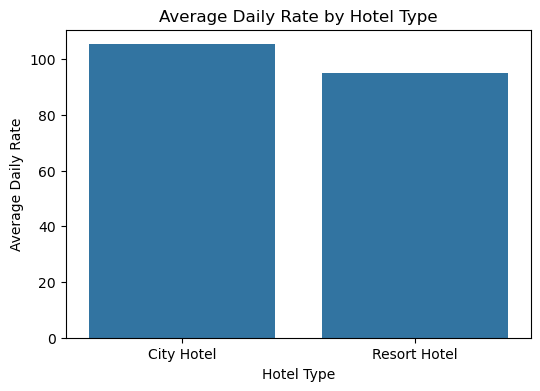

In [7]:
fig=plt.figure(figsize=(6,4))
sns.barplot(data=adr_by_hotel, x="hotel", y="adr")

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate")


In [8]:
fig.savefig(
    "screenshots/python_visuals/avg_adr_by_hoteltype.png",
    bbox_inches="tight"
)
plt.show()



In [9]:
cancel_by_hotel = (
    df.groupby("hotel")["is_canceled"]
      .mean()
      .reset_index()
)

cancel_by_hotel["is_canceled"] = cancel_by_hotel["is_canceled"] * 100

cancel_by_hotel


,hotel,is_canceled
0,City Hotel,41.726963
1,Resort Hotel,27.763355


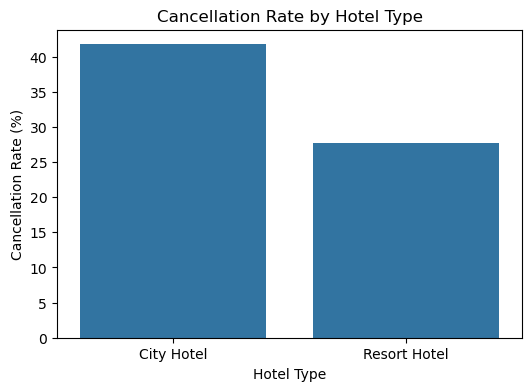

In [10]:
fig = plt.figure(figsize=(6,4))

sns.barplot(data=cancel_by_hotel, x="hotel", y="is_canceled")

plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate (%)")

fig.savefig(
    "screenshots/python_visuals/cancellation_rate_by_hotel.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()


In [11]:
monthly_cancel = (
    df.groupby("arrival_date_month")["is_canceled"]
      .mean()
      .reset_index()
)

monthly_cancel["is_canceled"] *= 100

monthly_cancel


,arrival_date_month,is_canceled
0,April,40.797186
1,August,37.753117
2,December,34.970501
3,February,33.415964
4,January,30.477315
5,July,37.453598
6,June,41.457172
7,March,32.152338
8,May,39.665847
9,November,31.233441


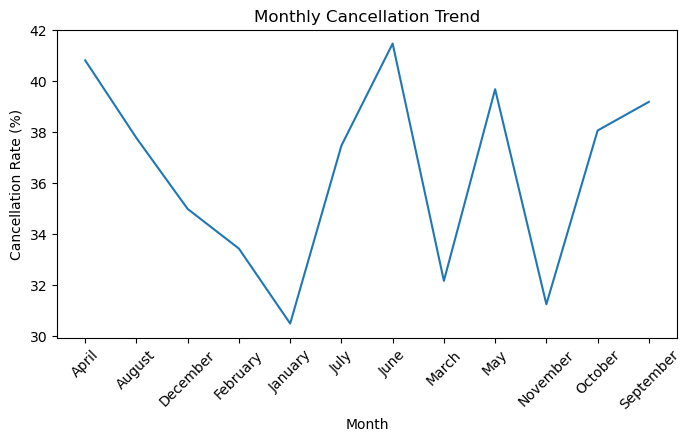

In [12]:
fig = plt.figure(figsize=(8,4))

sns.lineplot(data=monthly_cancel, x="arrival_date_month", y="is_canceled")

plt.title("Monthly Cancellation Trend")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")

plt.xticks(rotation=45)

fig.savefig(
    "screenshots/python_visuals/monthly_cancellation_trend.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()


In [13]:
df["revenue_lost"] = df["adr"] * df["is_canceled"]

revenue_loss = (
    df.groupby("hotel")["revenue_lost"]
      .sum()
      .reset_index()
)

revenue_loss


,hotel,revenue_lost
0,City Hotel,3465379.54
1,Resort Hotel,1176563.13


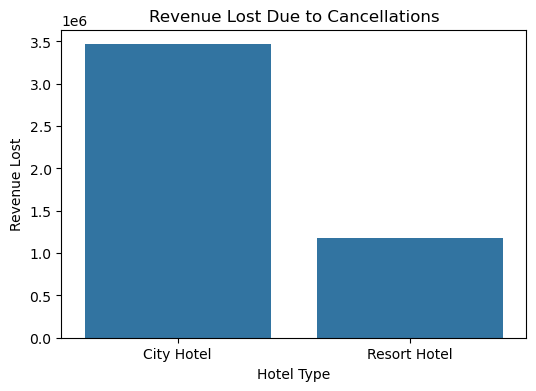

In [14]:
fig = plt.figure(figsize=(6,4))

sns.barplot(data=revenue_loss, x="hotel", y="revenue_lost")

plt.title("Revenue Lost Due to Cancellations")
plt.xlabel("Hotel Type")
plt.ylabel("Revenue Lost")

fig.savefig(
    "screenshots/python_visuals/revenue_loss_by_hotel.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
